Quatum digital circuits 
Mostly on theoretical inetrest - in practise is still a problem
Can be run on a real machine for presentation

The task will be just to implement the algorithm from the lecture, but the deriving is not trivial.

## PART ONE

- Grover algoriths is a basic search algorithm. We can also have other algorithms like Shor's algorithm for Fourier-Transform-Based algorithms
- Formal model of any classical computation is **Turing machine** ("universal machine with lot of overheads")
- Digital circuits: numbers, logic gates, wires (connectors), fan - out (possibility to split the wire), ancillas (extra bits for information storage, redundant for usual digital bits, but useful for quantum circuits)
- "Beautiful theorem": with NAND gates we can implement any boolean function (NAND is a universal gate)


- Lets go quantum circuit from the classical one!

- Basically all the quantum gates are unitary U * U_dagger = 1 (reversible), but the classical ones are not (e.g. AND, OR, NAND, NOR)
- Classical revertable gates: CNOT (controlled not, in quantum world CX - controlled X, but is not universal - i cannot buid any cuircit from it as from NAND in digital circuits), Toffoli (tripple gate, = CCNOT is a controlled-controlled-not, is universal for classical circuits, but not for quantum one, if i do it twice i'll undo the flip)
- NAND gate is not reversible, but we can make it reversible by adding an **ancilla bit** (extra bit for information storage) and using **Toffoli gate**. We can make such created NAND universal by applying FANout (possibility to split the wire) to the output of the NAND gate.
- Very intruiging observation: in QM the Quantum Toffoli (CCX) can be constructed from six 2-quibit CX gates (this is not possible classically), but assuming connectivity all to all, but on a real devide with limited connectivity, we need 12 CX gates to implement the Toffoli gate. So the connectivity of the device is very important for the efficiency of the algorithm. It's a complex gate but is implemented in Qiskit as a single gate (CCX), but in reality it is not.
- X = H Z H (H is the Hadamard gate, Z is the Pauli-Z gate)

- Let's take a N bit register (combinations of 0/1) and perform some classical transformation on this register that outputs 0/1. Very general.
- We want to now implement a quantum calculation given the know digital circuit for this transformation. We can do it by using the universal Toffoli gate and ancilla bits. We aim to have a uniformal operator U_f that performs the transformation on the quantum states x, y. The output is x, y XOR f(x) (XOR is the addition modulo 2). 

- The most democratic state is a superposition of all states |s> = 1/sqrt(2^N) sum_x |x>, where x is a N bit string. We can prepare this state by applying the Hadamard gate to each qubit in the register (H^N |0> = |s>). (source of parallelism in quantum computing) (with only one step we can prepare a superposition of all possible states, while classically we would need 2^N steps to do it, good for sudoku) But where is the proper one? We cant measure it, because we will get a random state (we will destroy the interference). We need to amplify the amplitude of the proper state, and this is what Grover's algorithm does.

## PART TWO

How to extract information form the most democtaric state? 

We need to amplify the amplitude of the proper state, and this is what Grover's algorithm does. We can do it by applying the operator G = (2|s><s| - 1) U_f, where U_f is the oracle that marks the proper state by flipping its sign (f(x) = 1 for the proper state, f(x) = 0 for the others). The operator G is called the Grover operator. It can be shown that after applying G O(sqrt(2^N)) times, we will get the proper state with high probability. This is a quadratic speedup compared to classical algorithms that would need O(2^N) steps to find the proper state.

1. unstructured database search: 

We have a database of N items, and we want to find a specific marked item (winner). Classically, we would need to check each item one by one, which would take O(N) time "brute force", classical complexity is exponential in teh size of binary register. With Grover's algorithm, we can find the item in O(sqrt(N)) time.

oracle - blackbox that contains function f that marks the winner by flipping its sign. We can implement this oracle using a quantum circuit that applies a phase flip to the marked state. returns 0/1 (0 for non-winner, 1 for winner - solution to the puzzle). 

2. algorithm
In quantum computing we can represent the database as a superposition of all possible states, and the oracle will flip the sign of the marked state. The Grover operator will then amplify the amplitude of the marked state, making it more likely to be measured when we perform a measurement on the quantum register.

classical oracle: f
quantum oracle on quantum register: U_w |x> = (-1)^(f(x)) |x> PHASE ORACLE - it flips the sign of the marked state, but does not change the amplitude. It is unitary so can operate on any superposition of states.

U_w |s> = 1/sqrt(2^N) sum_x (-1)^(f(x)) |x> to the most democtratic state

algebraic way: U_w = I - 2|w><w|, where |w> is the marked state. This means that U_w acts as the identity on all states except for the marked state, where it applies a phase flip.

time of operation: number of U_w applications is O(sqrt(N)) which is the number of U_w operations

3. complexity

U_S = 2|s><s| - I, where 2|s><s| - I is the diffusion operator that amplifies the amplitude of the marked state. The diffusion operator can be implemented using Hadamard gates and phase shifts. operating on the most democratic state |s> 

|<w| U_s U_w |s>|^2 = 1 - O(1/N) after O(sqrt(N)) iterations, which means that the probability of measuring the marked state is close to 1.// clear peaking of the histogram

one application of oracle gives 1/N (3 - 4/N)^2 which is higher the 1/N

|<w| (U_s U_w)^t |s>|^2 = sin^2 ((2t + 1)phi) - t is the time of computation, so max at pi/2 so phi = arc 1/sqrt(N) to t scales assimptotically as pi/4 (sqrt(N))so O(sqrt(N)). it's clasically mind-blowing, but quantumly it's just a simple calculation.


There is also a geomatric way to understand the algorithm. The state of the system can be represented as a vector in a two-dimensional space spanned by the marked state |w> and the superposition of all non-marked states |s'>. The Grover operator G can be seen as a rotation in this space that brings the state closer to the marked state |w>. After O(sqrt(N)) iterations, the state is close enough to |w> that measuring it will yield the marked state with high probability.

## PART 3: algorithm implementation

1. initiate the register in the most democtratic state |s> by applying the Hadamard gate to each qubit in the register.

2. ccz works as a phase oracle for the state |111> (the marked state) by flipping its sign. We can implement the diffusion operator U_s using Hadamard gates and phase shifts.

In [118]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [119]:
def prepare_s(n):
    circuit = QuantumCircuit(n)
    circuit.h(range(n))
    return circuit

In [120]:
from qiskit.quantum_info import Statevector

def print_wavefunction(qc, title = "Title"):
    
    print(f"{title}")
    sv = Statevector(qc)

    # inverse order 

    for basis_state, amplitude in sv.to_dict().items():
        print(f" ({amplitude.real:+.3f} {amplitude.imag:+.3f}*j | {basis_state})")
    print("-"*35)


In [121]:
print_wavefunction(prepare_s(3), "Most democratic state |s>")

Most democratic state |s>
 (+0.354 +0.000*j | 000)
 (+0.354 +0.000*j | 001)
 (+0.354 +0.000*j | 010)
 (+0.354 +0.000*j | 011)
 (+0.354 +0.000*j | 100)
 (+0.354 +0.000*j | 101)
 (+0.354 +0.000*j | 110)
 (+0.354 +0.000*j | 111)
-----------------------------------


In [138]:
def grover(s, marked_state = [0,1,1], qubits = [0,1,2]):

    # oracle
    for i, bit in enumerate(marked_state):
        if str(bit) == '0':
            s.x(i)
            
    s.ccz(qubits[0], qubits[1], qubits[2])
        
    for i, bit in enumerate(marked_state):
        if str(bit) == '0':
            s.x(i)

    s.barrier()
    print_wavefunction(s, "After oracle")

    # diffusion operator
    s.h(qubits)
    s.x(qubits)
        
    s.ccz(qubits[0], qubits[1], qubits[2])
    
    s.x(qubits)
    s.h(qubits)

    print_wavefunction(s, "After diffuson operator")

    s.measure_all()

    
    return s

In [158]:
def double_grover(s, marked_state = [0,1,1], qubits = [0,1,2]):

    # oracle
    for i, bit in enumerate(marked_state):
        if str(bit) == '0':
            s.x(i)
            
    s.ccz(qubits[0], qubits[1], qubits[2])
        
    for i, bit in enumerate(marked_state):
        if str(bit) == '0':
            s.x(i)

    s.barrier()
    print_wavefunction(s, "After oracle # 1")

    # diffusion operator
    s.h(qubits)
    s.x(qubits)
        
    s.ccz(qubits[0], qubits[1], qubits[2])
    
    s.x(qubits)
    s.h(qubits)

    s.barrier()
    print_wavefunction(s, "After diffuson operator # 1")

    # oracle
    for i, bit in enumerate(marked_state):
        if str(bit) == '0':
            s.x(i)
            
    s.ccz(qubits[0], qubits[1], qubits[2])
        
    for i, bit in enumerate(marked_state):
        if str(bit) == '0':
            s.x(i)

    s.barrier()
    print_wavefunction(s, "After oracle # 2")

    # diffusion operator
    s.h(qubits)
    s.x(qubits)
        
    s.ccz(qubits[0], qubits[1], qubits[2])
    
    s.x(qubits)
    s.h(qubits)

    s.barrier()
    print_wavefunction(s, "After diffuson operator # 2")

    s.measure_all()

    
    return s

After oracle
 (+0.354 +0.000*j | 000)
 (+0.354 +0.000*j | 001)
 (+0.354 +0.000*j | 010)
 (+0.354 +0.000*j | 011)
 (+0.354 +0.000*j | 100)
 (+0.354 +0.000*j | 101)
 (-0.354 +0.000*j | 110)
 (+0.354 +0.000*j | 111)
-----------------------------------
After diffuson operator
 (-0.177 +0.000*j | 000)
 (-0.177 +0.000*j | 001)
 (-0.177 +0.000*j | 010)
 (-0.177 +0.000*j | 011)
 (-0.177 +0.000*j | 100)
 (-0.177 +0.000*j | 101)
 (-0.884 +0.000*j | 110)
 (-0.177 +0.000*j | 111)
-----------------------------------


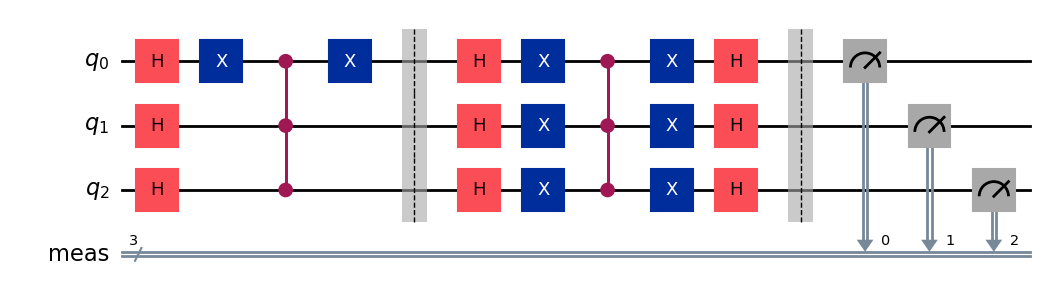

In [142]:
full_circuit = grover(prepare_s(3), marked_state = [0,1,1])
fig = full_circuit.draw("mpl")
fig

In [160]:
full_circuit_double = double_grover(prepare_s(3), marked_state = [0,1,1])

After oracle # 1
 (+0.354 +0.000*j | 000)
 (+0.354 +0.000*j | 001)
 (+0.354 +0.000*j | 010)
 (+0.354 +0.000*j | 011)
 (+0.354 +0.000*j | 100)
 (+0.354 +0.000*j | 101)
 (-0.354 +0.000*j | 110)
 (+0.354 +0.000*j | 111)
-----------------------------------
After diffuson operator # 1
 (-0.177 +0.000*j | 000)
 (-0.177 +0.000*j | 001)
 (-0.177 +0.000*j | 010)
 (-0.177 +0.000*j | 011)
 (-0.177 +0.000*j | 100)
 (-0.177 +0.000*j | 101)
 (-0.884 +0.000*j | 110)
 (-0.177 +0.000*j | 111)
-----------------------------------
After oracle # 2
 (-0.177 +0.000*j | 000)
 (-0.177 +0.000*j | 001)
 (-0.177 +0.000*j | 010)
 (-0.177 +0.000*j | 011)
 (-0.177 +0.000*j | 100)
 (-0.177 +0.000*j | 101)
 (+0.884 +0.000*j | 110)
 (-0.177 +0.000*j | 111)
-----------------------------------
After diffuson operator # 2
 (-0.088 +0.000*j | 000)
 (-0.088 +0.000*j | 001)
 (-0.088 +0.000*j | 010)
 (-0.088 +0.000*j | 011)
 (-0.088 +0.000*j | 100)
 (-0.088 +0.000*j | 101)
 (+0.972 +0.000*j | 110)
 (-0.088 +0.000*j | 111)
--

In [161]:
def run_grover(circuit = full_circuit, N=1000, title = "Grover's Algorithm Results 1 iteration"):
    
    sampler = Sampler()
    job = sampler.run([circuit], shots=N)
    result = job.result()

    counts = result[0].data.meas.get_counts()

    plt.bar(counts.keys(), (np.array(list(counts.values())) / N) * 100)
    print( max(counts.values()) / N * 100)
    plt.xlabel("Measured state")
    plt.ylabel("Probability [%]")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

75.3


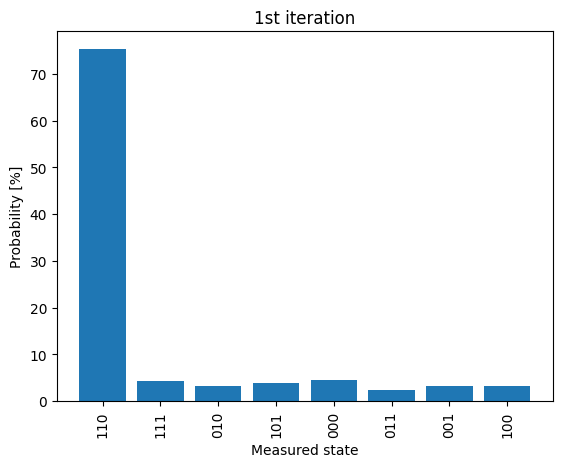

95.0


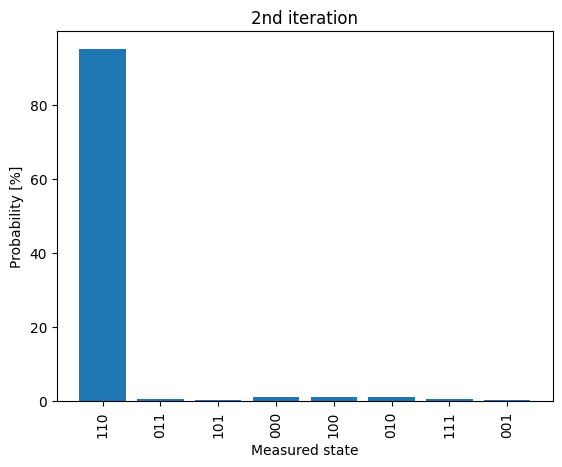

In [ ]:
run_grover(circuit = full_circuit, N=1000, title = "1st iteration")
run_grover(circuit = full_circuit_double, N=1000, title = "2nd iteration")